In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("../train.csv")
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [26]:
# What percentage of passengers survived?
train["Survived"].mean()

np.float64(0.3838383838383838)

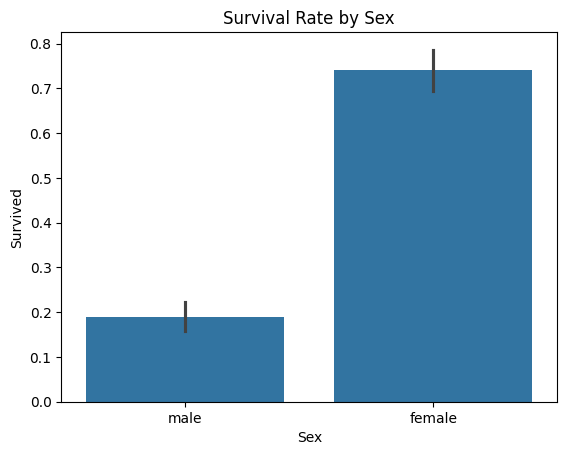

In [27]:
# Survival by Sex
train.groupby("Sex")["Survived"].mean()

# visualization
sns.barplot(x="Sex", y="Survived", data=train)
plt.title("Survival Rate by Sex")
plt.show()

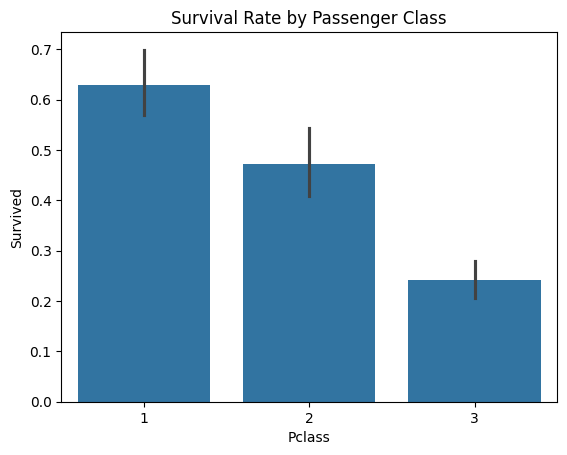

In [28]:
# Survival by Passenger Class
train.groupby("Pclass")["Survived"].mean()

sns.barplot(x="Pclass", y="Survived", data=train)
plt.title("Survival Rate by Passenger Class")
plt.show()

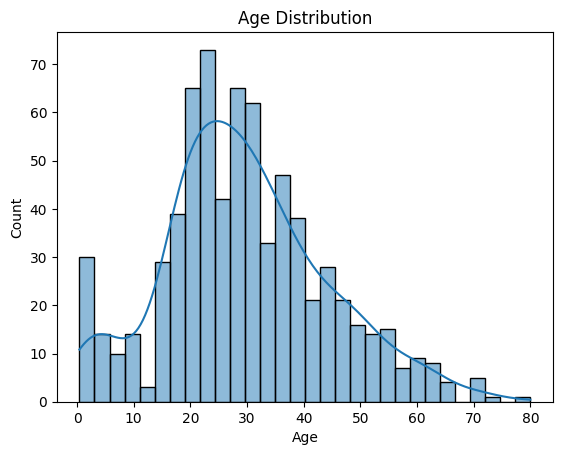

In [29]:
# Plot a histogram of the Age column
# This shows how passenger ages are distributed across ranges
# bins=30 divides the age range into 30 intervals
# kde=True overlays a smooth density curve on top of the histogram
sns.histplot(train["Age"], bins=30, kde=True)

# Add a title to make the plot readable
plt.title("Age Distribution")

# Display the plot
plt.show()

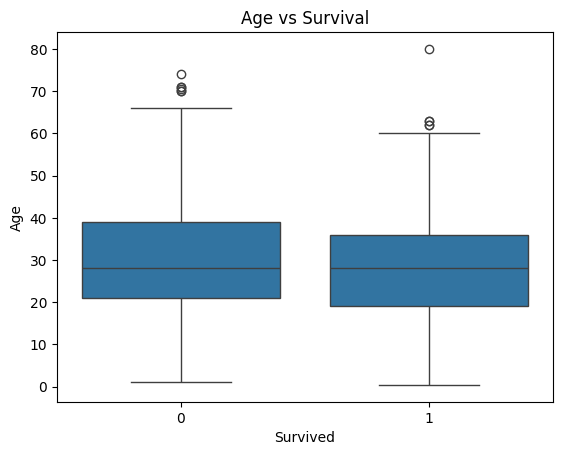

In [30]:
# Create a boxplot to compare age distributions
# x="Survived" splits the data into two groups (0 = died, 1 = survived)
# y="Age" shows the distribution of ages within each group
sns.boxplot(x="Survived", y="Age", data=train)

# Add a title for clarity
plt.title("Age vs Survival")

# Display the plot
plt.show()

In [31]:
# Import the Random Forest classifier
# This is an ensemble model that builds many decision trees
# and combines their predictions for better performance
from sklearn.ensemble import RandomForestClassifier

# Import train_test_split
# This function allows us to split the dataset into training and validation sets
from sklearn.model_selection import train_test_split


# --------------------------------------------------
# DEFINE FEATURES
# --------------------------------------------------

# Select the input variables (features) we want the model to use.
# These were chosen based on exploratory data analysis (EDA)
# and domain knowledge about the Titanic dataset.
features = ["Pclass", "Sex", "Age", "SibSp", "Parch"]


# --------------------------------------------------
# PREPARE X (INPUTS) AND y (TARGET)
# --------------------------------------------------

# X contains only the selected feature columns.
# pd.get_dummies converts categorical variables (like "Sex")
# into numeric columns using one-hot encoding.
# Example:
#   Sex = male/female
# becomes:
#   Sex_male (0/1), Sex_female (0/1)
X = pd.get_dummies(train[features])

# y is the target variable we want to predict.
# Survived = 1 means passenger survived
# Survived = 0 means passenger did not survive
y = train["Survived"]


# --------------------------------------------------
# TRAIN / VALIDATION SPLIT
# --------------------------------------------------

# Split the dataset into two parts:
#  - 80% for training the model
#  - 20% for validating model performance
#
# random_state ensures reproducibility (same split every run).
# stratify=y keeps the survival ratio balanced in both sets,
# preventing class imbalance distortion.
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1,
    stratify=y
)


# --------------------------------------------------
# TRAIN THE MODEL
# --------------------------------------------------

# Initialize the Random Forest model.
#
# n_estimators = number of trees in the forest.
# More trees usually improve stability but increase computation.
#
# max_depth = maximum depth of each tree.
# Limiting depth helps prevent overfitting.
#
# random_state = ensures consistent results across runs.
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=1
)

# Fit the model on the training data.
# The model learns patterns between X_train and y_train.
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

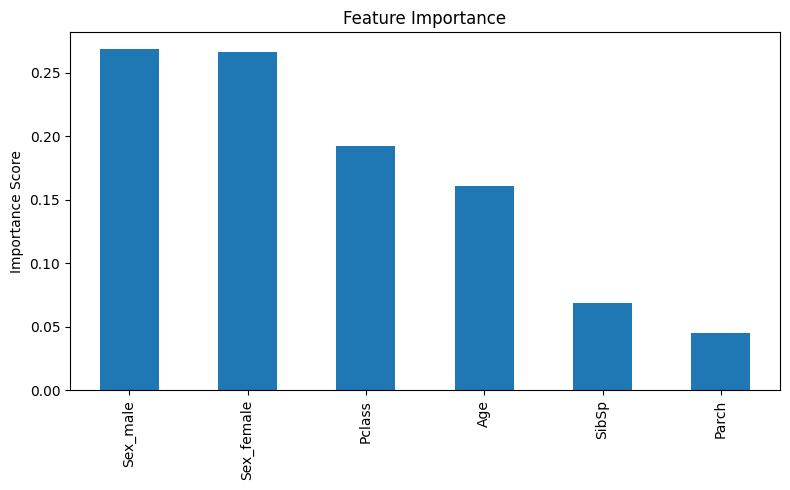

In [ ]:
# Import matplotlib for plotting visualizations
import matplotlib.pyplot as plt


# --------------------------------------------------
# EXTRACT FEATURE IMPORTANCE
# --------------------------------------------------

# Random Forest calculates how important each feature was
# in reducing classification error across all decision trees.
# The result is an array of importance scores (one per feature).
importances = model.feature_importances_


# --------------------------------------------------
# GET FEATURE NAMES
# --------------------------------------------------

# X.columns contains the names of the features after one-hot encoding.
# These are needed so we can match each importance score
# to the correct feature name.
feature_names = X.columns


# --------------------------------------------------
# ORGANIZE AND SORT IMPORTANCE SCORES
# --------------------------------------------------

# Create a pandas Series that maps:
#   feature_name -> importance_score
feat_importance = pd.Series(importances, index=feature_names)

# Sort features from most important to least important.
# This makes the plot easier to interpret.
feat_importance = feat_importance.sort_values(ascending=False)

# --------------------------------------------------
# CREATE AND SAVE FEATURE IMPORTANCE PLOT
# --------------------------------------------------

# Create a new matplotlib figure.
# figsize controls the width and height of the plot (in inches).
plt.figure(figsize=(8, 5))


# Plot the feature importance values as a bar chart.
# feat_importance is a sorted pandas Series:
#   index  → feature names
#   values → importance scores
feat_importance.plot(kind="bar")


# Add a descriptive title to the chart.
plt.title("Feature Importance")


# Label the y-axis to clarify what the bar values represent.
plt.ylabel("Importance Score")


# Automatically adjust spacing so labels and titles do not overlap.
# This prevents cropping when saving the image.
plt.tight_layout()


# Save the figure as a PNG image file.
#
# "../images/" means:
#   - Go up one directory from notebooks/
#   - Enter the images/ folder
#
# dpi=300 ensures high resolution (good for GitHub rendering).
plt.savefig("../images/feature_importance.png", dpi=300)


# Display the plot inside the notebook output.
plt.show()